# Comparing Results from 4 Regression Models: Timepoint T2 Models
### ElasticNet, Support Vector Regression, Partial Least Squares Regression, HistGradientBoosting Regressor

In [1]:
# Importing and loading results
import sys, os
sys.path.insert(0, '../src')
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skrub import TableReport
import joblib, os
import preprocess
import explore
import model
os.environ['PYTHONWARNINGS'] = 'ignore'
MODEL_DIR = os.path.abspath('../models/pain-reduction')

# Performance Metrics against Selected Features
### From Feature Frequency Lists

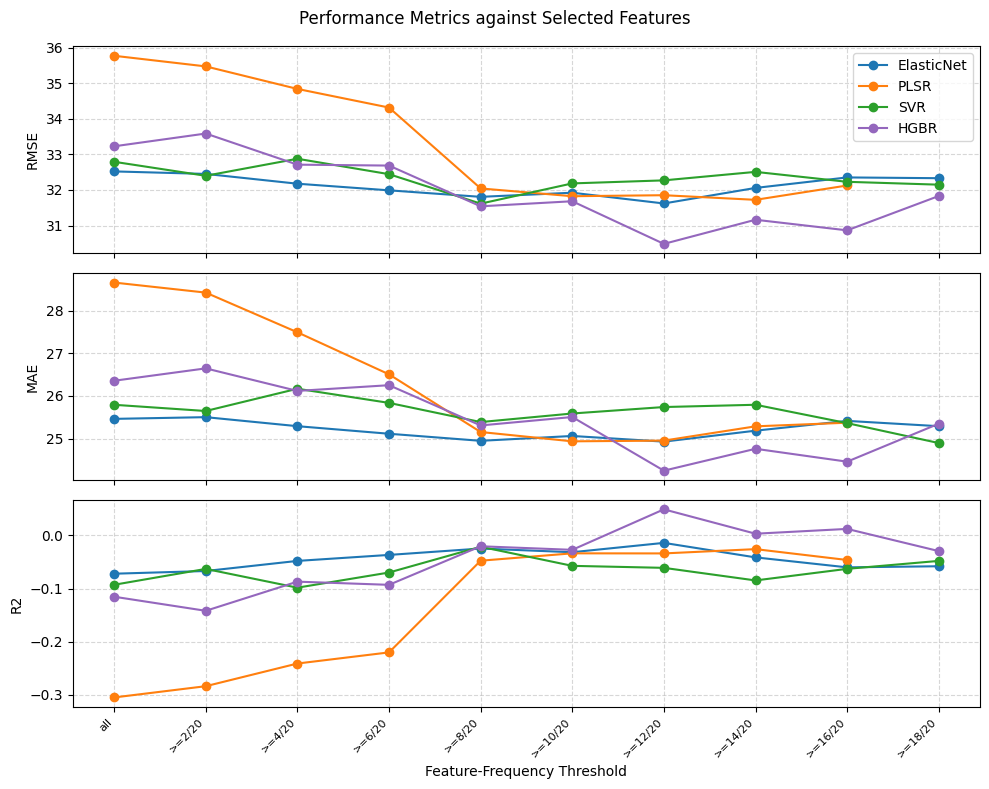

In [3]:
en_sweep = joblib.load(os.path.join(MODEL_DIR, 'en_sweep_df.pkl'))
svr_sweep = joblib.load(os.path.join(MODEL_DIR, 'svr_sweep_df.pkl'))
pls_sweep = joblib.load(os.path.join(MODEL_DIR, 'pls_sweep_df.pkl'))
hgbr_sweep = joblib.load(os.path.join(MODEL_DIR, 'hgbr_sweep_df.pkl'))
importlib.reload(model)
model.plot_sweep({'ElasticNet': en_sweep,
        'PLSR':   pls_sweep,
        'SVR':        svr_sweep,
        'HGBR':       hgbr_sweep}, title='Performance Metrics against Selected Features')

## Summary: Mean Performance Metrics for All T2 Final Models

In [ ]:
import pandas as pd
# Summary from Modeling-Notebooks
summary = pd.DataFrame({
    'Model':               ['ElasticNet',         'SVR',             'PLSR',          'HGBR'],
    'Cut-Off Feature sel.':['>=12/20',           '>=8/20',        '>=14/20',      '>=12/20'],
    'Mean RMSE':           ['31.621 ± 2.9158', '31.616 ± 2.628', '31.723 ± 2.901', '30.608 ± 3.5390'],
    'Mean MAE':            ['24.931 ± 2.4423', '25.389 ± 2.171', '25.289 ± 2.615', '24.212 ± 3.024'],
    'Mean R2':             ['-0.014 ± 0.1085','-0.021 ± 0.1612', '-0.026 ± 0.1625','0.042 ± 0.1937'],
})

summary.set_index('Model', inplace=True)
display(summary)

,Cut-Off Feature sel.,Mean RMSE,Mean MAE,Mean R2
Model,,,,
ElasticNet,>=12/20,31.621 ± 2.9158,24.931 ± 2.4423,-0.014 ± 0.1085
SVR,>=8/20,31.616 ± 2.628,25.389 ± 2.171,-0.021 ± 0.1612
PLSR,>=14/20,31.723 ± 2.901,25.289 ± 2.615,-0.026 ± 0.1625
HGBR,>=12/20,30.608 ± 3.5390,24.212 ± 3.024,0.042 ± 0.1937


## Significance testing
# Pairwise t-tests between Model Performance Metrics
Comparing performance metrics across 4 models, computing p-values and plotting heatmaps


  Pairwise Paired t-test (α=0.05)

  ElasticNet vs SVR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.9877      no
  MAE          0.1313      no
  R2           0.7159      no

  ElasticNet vs PLSR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.6669      no
  MAE          0.1567      no
  R2           0.5042      no

  ElasticNet vs HGBR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.0674      no
  MAE          0.2515      no
  R2           0.0962      no

  SVR vs PLSR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.7464      no
  MAE          0.7771      no
  R2           0.8409      no

  SVR vs HGBR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.0841      no
  MAE          0.0642      no
  R2           0.0783      no

  PLSR vs HGBR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.0490    *YES
  MAE   

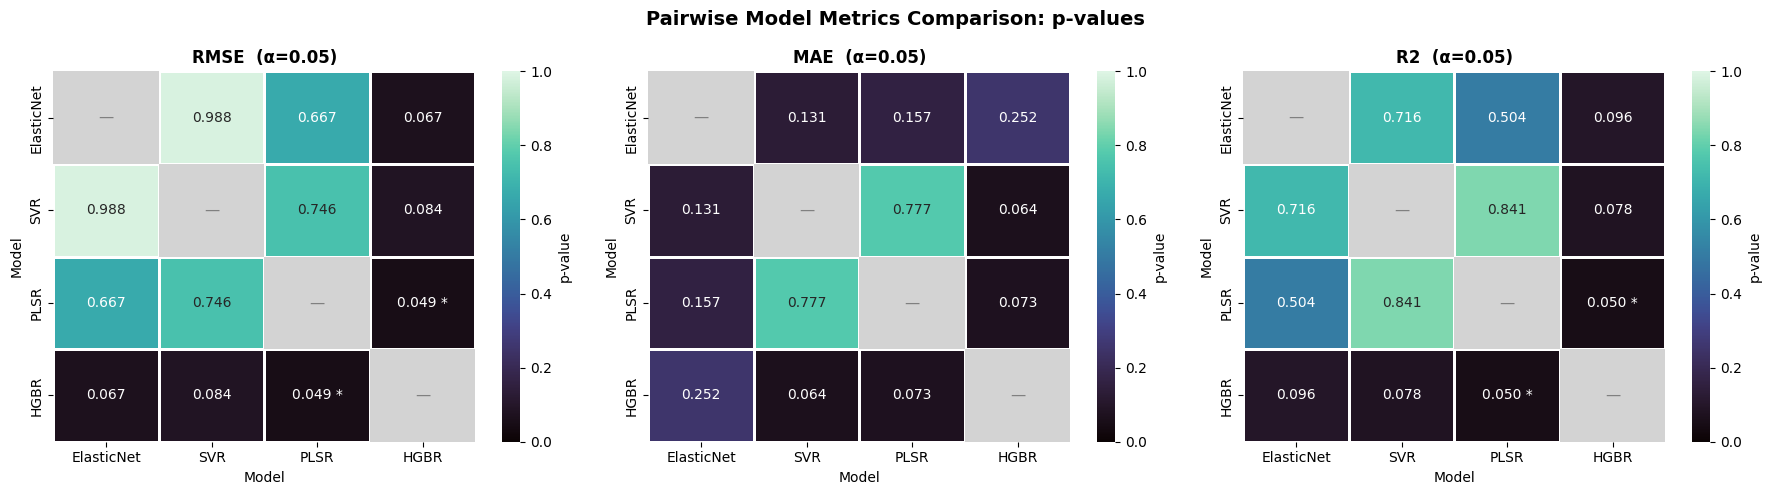

In [5]:
importlib.reload(model)
results_dict = {
    'ElasticNet': joblib.load(os.path.join(MODEL_DIR, 'en_results_df.pkl')),
    'SVR':        joblib.load(os.path.join(MODEL_DIR, 'svr_results.pkl')),
    'PLSR':        joblib.load(os.path.join(MODEL_DIR, 'pls_results.pkl')),
    'HGBR':       joblib.load(os.path.join(MODEL_DIR, 'hgbr_results.pkl')),
}

p_vals = model.pairwise_metric_comparison(results_dict, alpha=0.05)